In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/lakshmi25npathi/bike-sharing-dataset/hour.csv
/kaggle/input/datasets/lakshmi25npathi/bike-sharing-dataset/Readme.txt
/kaggle/input/datasets/lakshmi25npathi/bike-sharing-dataset/day.csv


In [2]:
df=pd.read_csv('/kaggle/input/datasets/lakshmi25npathi/bike-sharing-dataset/day.csv')
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [4]:
# # clean

df=df.drop(['dteday', 'instant', 'casual', 'registered', 'atemp'],axis=1)

# Split features/target
X = df.drop("cnt", axis=1).values
y = df["cnt"].values  # keep 1D for KFold

df.head()


# =========================
# 1. HONEST CLEANING
# =========================
# Drop columns that are 'results' or useless for prediction
# cols_to_drop = ['dteday', 'instant', 'casual', 'registered', 'atemp']
# df_clean = df.drop(columns=cols_to_drop, errors='ignore')


# cols_to_drop = ['dteday', 'instant', 'casual', 'registered', 'atemp']
# df_clean = df.drop(columns=cols_to_drop, errors='ignore')

# # Now define X and y from the CLEAN dataframe
# X = df_clean.drop("cnt", axis=1).values
# y = df_clean["cnt"].values 

# print(f"Features used for training: {df_clean.drop('cnt', axis=1).columns.tolist()}")

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed,cnt
0,1,0,1,0,6,0,2,0.344167,0.805833,0.160446,985
1,1,0,1,0,0,0,2,0.363478,0.696087,0.248539,801
2,1,0,1,0,1,1,1,0.196364,0.437273,0.248309,1349
3,1,0,1,0,2,1,1,0.200000,0.590435,0.160296,1562
4,1,0,1,0,3,1,1,0.226957,0.436957,0.186900,1600


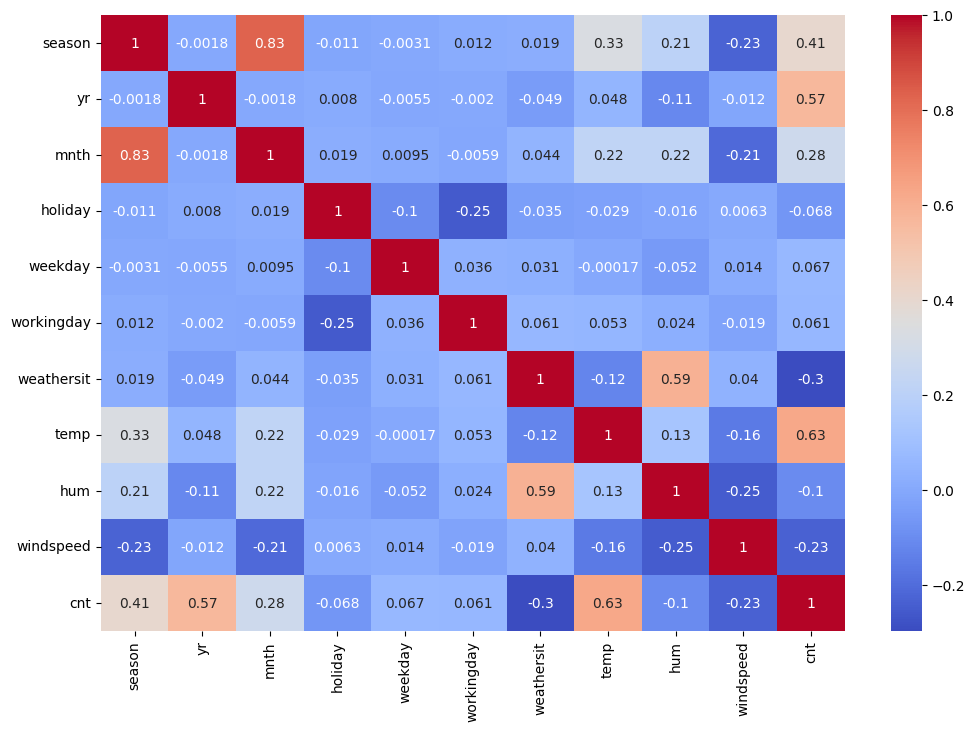

In [5]:

# feature selection 

import seaborn as sns
import matplotlib.pyplot as plt

# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
# sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()


# temp and atemp (0.63): These have a strong positive correlation. This means as the temperature increases, bike rentals increase significantly. This is your strongest environmental predictor.
# yr (0.57): This shows a strong positive correlation. It means the bike-sharing service became much more popular in the second year compared to the first.
# weathersit (-0.3): This is a negative correlation. In this dataset, a higher "weathersit" number means worse weather (1=Clear, 3=Rain). So, as weather gets worse, rentals go down.
# hum (-0.1) and windspeed (-0.23): Both are negative. High humidity and high wind slightly discourage people from biking.


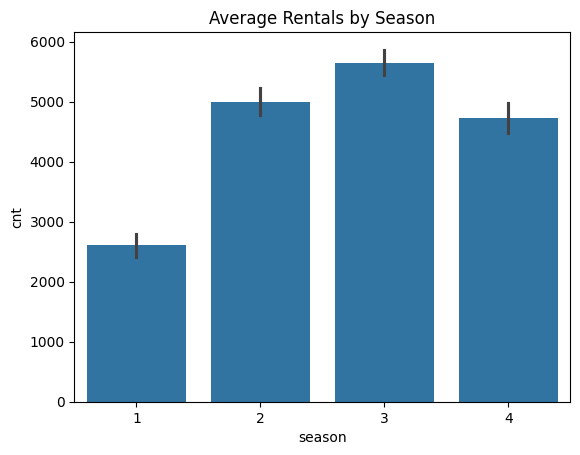

In [6]:
sns.barplot(data=df, x='season', y='cnt')
plt.title('Average Rentals by Season')
plt.show()

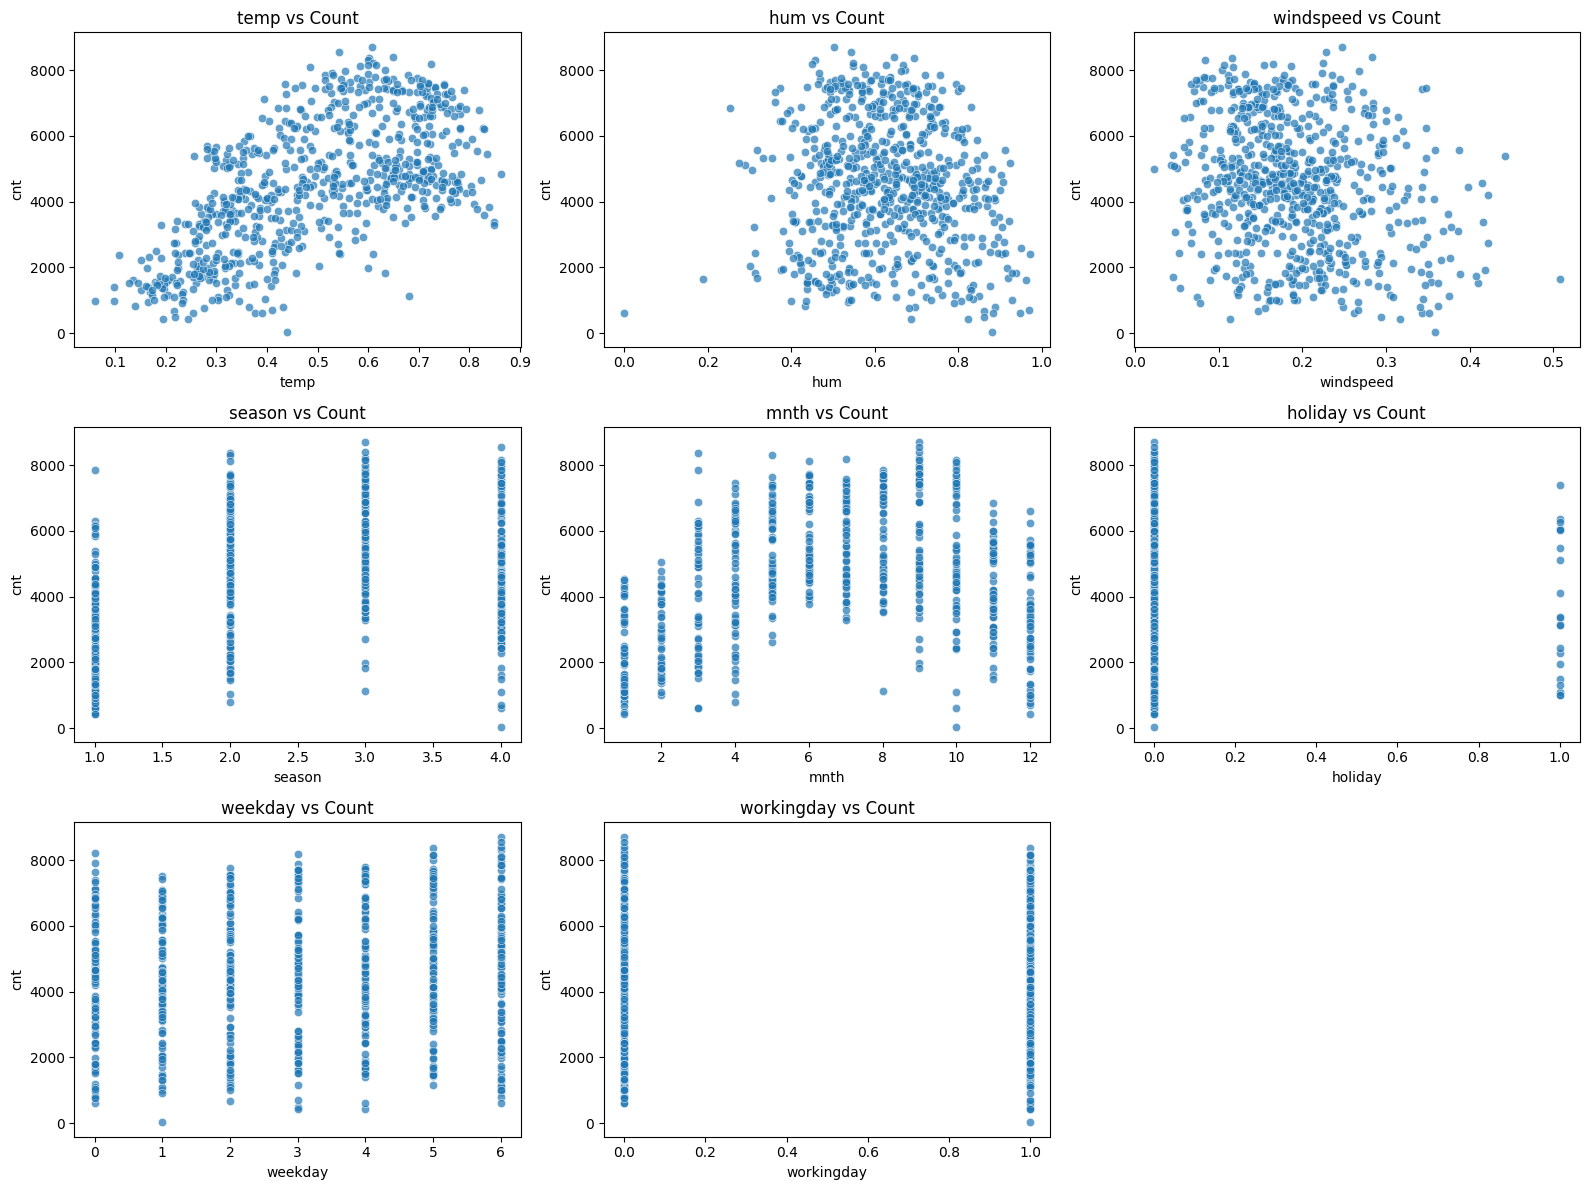

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the features we want to check (numeric ones)
features = ['temp', 'hum', 'windspeed', 'season', 'mnth', 'holiday', 'weekday', 'workingday']

# Create a figure with subplots
plt.figure(figsize=(16, 12))

for i, col in enumerate(features):
    plt.subplot(3, 3, i + 1)
    sns.scatterplot(data=df, x=col, y='cnt', alpha=0.7)
    plt.title(f'{col} vs Count')

plt.tight_layout()
plt.show()

In [8]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# ==========================================
# 2. SPLIT AND SCALE
# ==========================================

y = y.reshape(-1, 1) # Reshape for PyTorch (N, 1)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler_x = StandardScaler()
scaler_y = StandardScaler() # Scaling target 'y' helps Neural Networks converge faster

X_train = scaler_x.fit_transform(X_train)
X_test = scaler_x.transform(X_test)

y_train = scaler_y.fit_transform(y_train)
y_test = scaler_y.transform(y_test)

In [9]:
# Convert to PyTorch Tensors

import torch

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)



# import torch
# import torch.nn as nn
# import numpy as np

# # Check if it worked
# print(f"PyTorch Version: {torch.__version__}")

# # Only convert if the variables exist
# if 'X_train' in locals():
#     X_train_tensor = torch.tensor(np.array(X_train), dtype=torch.float32)
#     y_train_tensor = torch.tensor(np.array(y_train), dtype=torch.float32)
#     print("Conversion successful!")

Epoch [10/100], Loss: 0.2373
Epoch [20/100], Loss: 0.1482
Epoch [30/100], Loss: 0.1170
Epoch [40/100], Loss: 0.0932
Epoch [50/100], Loss: 0.0786
Epoch [60/100], Loss: 0.0661
Epoch [70/100], Loss: 0.0563
Epoch [80/100], Loss: 0.0485
Epoch [90/100], Loss: 0.0422
Epoch [100/100], Loss: 0.0368


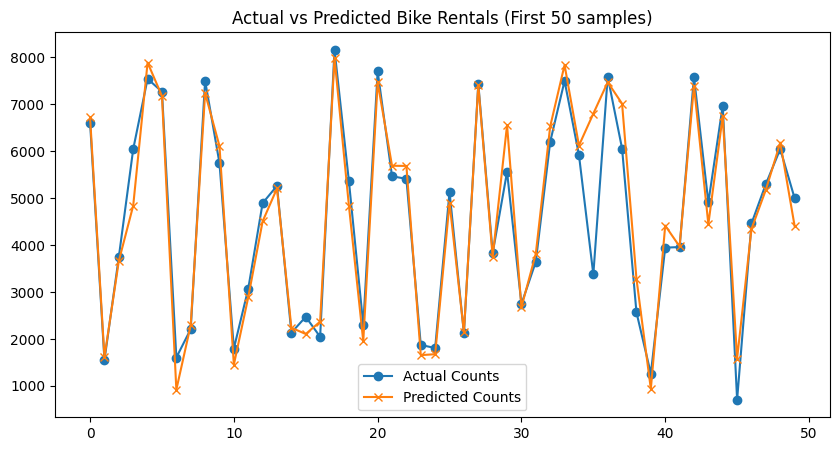

📊 R2 Score (Variance Explained): 0.8886
🚲 Average Error: 447.98 bikes


In [10]:

import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


# ==========================================
# 3. DEFINE MODEL ARCHITECTURE
# ==========================================
class BikeRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super(BikeRegressionModel, self).__init__()
        self.layer1 = nn.Linear(input_dim, 64)
        self.layer2 = nn.Linear(64, 32)
        self.output = nn.Linear(32, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.output(x)
        return x

input_dim = X_train.shape[1]
model = BikeRegressionModel(input_dim)

# ==========================================
# 4. LOSS AND OPTIMIZER
# ==========================================
criterion = nn.MSELoss() # Mean Squared Error for Regression
optimizer = optim.Adam(model.parameters(), lr=0.01)

# ==========================================
# 5. TRAINING LOOP
# ==========================================
epochs = 100
train_losses = []

for epoch in range(epochs):
    model.train()
    
    # Forward Pass
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    
    # Backward Pass (Optimization)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    train_losses.append(loss.item())
    
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

# ==========================================
# 6. EVALUATION & VISUALIZATION
# ==========================================
model.eval()
with torch.no_grad():
    predictions = model(X_test)
    # Convert back to original scale (un-scale) to see real bike counts
    predictions_unscaled = scaler_y.inverse_transform(predictions)
    y_test_unscaled = scaler_y.inverse_transform(y_test)

# Plotting Results
plt.figure(figsize=(10, 5))
plt.plot(y_test_unscaled[:50], label='Actual Counts', marker='o')
plt.plot(predictions_unscaled[:50], label='Predicted Counts', marker='x')
plt.title('Actual vs Predicted Bike Rentals (First 50 samples)')
plt.legend()
plt.show()


from sklearn.metrics import r2_score, mean_absolute_error

model.eval()
with torch.no_grad():
    predictions = model(X_test)
    
    # Unscale everything to see real bike numbers
    y_true = scaler_y.inverse_transform(y_test)
    y_pred = scaler_y.inverse_transform(predictions)

    # 1. R2 Score (The "Accuracy" of Regression)
    # 1.0 is perfect, 0.0 is terrible.
    r2 = r2_score(y_true, y_pred)
    
    # 2. MAE (Mean Absolute Error)
    # Tells you: "On average, our prediction is off by X bikes"
    mae = mean_absolute_error(y_true, y_pred)

print(f"📊 R2 Score (Variance Explained): {r2:.4f}")
print(f"🚲 Average Error: {mae:.2f} bikes")